In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("../   ../data/Clean_BNPParibas_Data.csv")

print(df.shape)

display(df.head())

(911, 10)


,customer_id,age,tenure_months,monthly_charges,total_charges,contract_type,internet_service,support_tickets,payment_method,churn
0,1,56,15,59.23,929.62,Month-to-Month,Fiber,5,UPI,1
1,2,69,64,24.20,1613.60,Month-to-Month,Fiber,1,Credit Card,1
2,3,46,28,78.02,2053.63,One Year,Fiber,1,UPI,0
3,4,32,39,45.95,1688.47,Month-to-Month,Fiber,1,UPI,0
4,6,25,17,53.02,850.81,Two Year,DSL,0,Cash,0


In [3]:
X_cluster = df.drop(
    columns=[
        "customer_id",
        "contract_type"
    ]
)

In [4]:
numeric_features = X_cluster.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_cluster.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numeric features:
['age', 'tenure_months', 'monthly_charges', 'total_charges', 'support_tickets', 'churn']

Categorical features:
['internet_service', 'payment_method']


In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

gmm_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

In [6]:
X_gmm = gmm_preprocessor.fit_transform(X_cluster)

print(X_gmm.shape)

(911, 12)


In [7]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(
    n_components=3,
    random_state=42
)

gmm.fit(X_gmm)

gmm_labels = gmm.predict(X_gmm)

In [8]:
gmm_df = df.copy()

gmm_df["Cluster"] = gmm_labels

display(gmm_df.head())

,customer_id,age,tenure_months,monthly_charges,total_charges,contract_type,internet_service,support_tickets,payment_method,churn,Cluster
0,1,56,15,59.23,929.62,Month-to-Month,Fiber,5,UPI,1,1
1,2,69,64,24.20,1613.60,Month-to-Month,Fiber,1,Credit Card,1,0
2,3,46,28,78.02,2053.63,One Year,Fiber,1,UPI,0,1
3,4,32,39,45.95,1688.47,Month-to-Month,Fiber,1,UPI,0,0
4,6,25,17,53.02,850.81,Two Year,DSL,0,Cash,0,1


In [9]:
gmm_probabilities = gmm.predict_proba(X_gmm)

gmm_df["Cluster_0_Probability"] = (
    gmm_probabilities[:, 0]
)

gmm_df["Cluster_1_Probability"] = (
    gmm_probabilities[:, 1]
)

gmm_df["Cluster_2_Probability"] = (
    gmm_probabilities[:, 2]
)

In [10]:
display(
    gmm_df[
        [
            "customer_id",
            "Cluster",
            "Cluster_0_Probability",
            "Cluster_1_Probability",
            "Cluster_2_Probability"
        ]
    ].head(10)
)

,customer_id,Cluster,Cluster_0_Probability,Cluster_1_Probability,Cluster_2_Probability
0,1,1,6.040770e-04,9.993959e-01,4.946411e-10
1,2,0,9.896495e-01,1.024348e-73,1.035054e-02
2,3,1,1.306532e-03,9.743499e-01,2.434358e-02
3,4,0,9.998516e-01,4.288367e-12,1.484043e-04
4,6,1,1.887042e-03,9.981130e-01,1.126626e-10
5,8,1,2.955518e-04,9.984505e-01,1.253964e-03
6,9,1,2.019030e-02,9.798097e-01,1.254162e-11
7,10,1,3.676565e-23,9.994914e-01,5.086339e-04
8,11,2,1.854039e-09,3.508076e-01,6.491924e-01
9,12,2,5.805429e-04,5.009076e-32,9.994195e-01


In [11]:
gmm_df["Cluster_Probability"] = (
    gmm_probabilities.max(axis=1)
)

display(
    gmm_df[
        [
            "customer_id",
            "Cluster",
            "Cluster_Probability"
        ]
    ].head(10)
)

,customer_id,Cluster,Cluster_Probability
0,1,1,0.999396
1,2,0,0.989649
2,3,1,0.974350
3,4,0,0.999852
4,6,1,0.998113
5,8,1,0.998450
6,9,1,0.979810
7,10,1,0.999491
8,11,2,0.649192
9,12,2,0.999419


In [12]:
from sklearn.decomposition import PCA

pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(X_gmm)

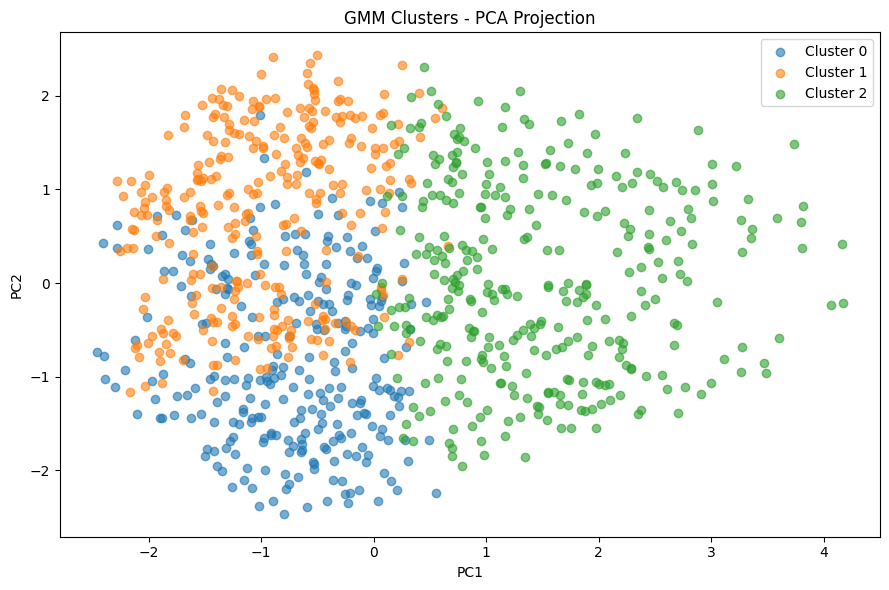

In [13]:
pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Cluster": gmm_labels
})

import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

for cluster in sorted(
    pca_df["Cluster"].unique()
):

    cluster_data = pca_df[
        pca_df["Cluster"] == cluster
    ]

    plt.scatter(
        cluster_data["PC1"],
        cluster_data["PC2"],
        label=f"Cluster {cluster}",
        alpha=0.6
    )

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title(
    "GMM Clusters - PCA Projection"
)

plt.legend()

plt.tight_layout()
plt.show()

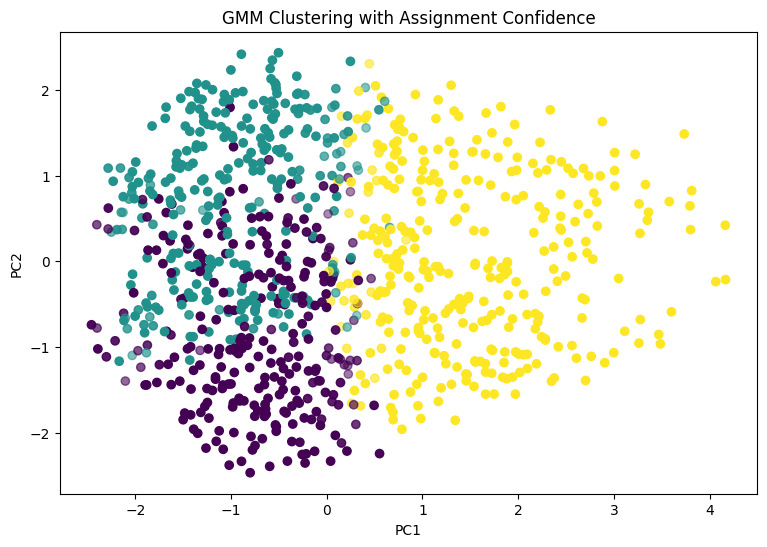

In [14]:
confidence = gmm_probabilities.max(
    axis=1
)

plt.figure(figsize=(9, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=gmm_labels,
    alpha=confidence
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title(
    "GMM Clustering with Assignment Confidence"
)

plt.show()

In [15]:
from sklearn.metrics import silhouette_score

gmm_results = []

for n in range(2, 7):

    model = GaussianMixture(
        n_components=n,
        random_state=42
    )

    labels = model.fit_predict(
        X_gmm
    )

    score = silhouette_score(
        X_gmm,
        labels
    )

    gmm_results.append({
        "Clusters": n,
        "Silhouette Score": score,
        "AIC": model.aic(X_gmm),
        "BIC": model.bic(X_gmm)
    })

gmm_results = pd.DataFrame(
    gmm_results
)

display(gmm_results)

,Clusters,Silhouette Score,AIC,BIC
0,2,0.132139,-3279.266301,-2407.834036
1,3,0.135892,-4081.747584,-2772.191916
2,4,0.046277,-27860.760167,-26113.081096
3,5,0.095069,-15302.691015,-13116.888539
4,6,0.065791,-29135.277841,-26511.351962
